In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
glucose = df["Glucose"]

print("Selected Variable: Glucose")
print("Number of observations:", len(glucose))
print("Original Sample Mean:", glucose.mean())

Selected Variable: Glucose
Number of observations: 768
Original Sample Mean: 120.89453125


In [7]:
np.random.seed(42)

n_bootstrap = 10000
sample_size = len(glucose)

bootstrap_means = []

for i in range(n_bootstrap):
    bootstrap_sample = np.random.choice(
        glucose,
        size=sample_size,
        replace=True
    )
    
    bootstrap_mean = np.mean(bootstrap_sample)
    bootstrap_means.append(bootstrap_mean)

bootstrap_means = np.array(bootstrap_means)

print("Number of bootstrap samples:", n_bootstrap)
print("Bootstrap sampling completed successfully!")

Number of bootstrap samples: 10000
Bootstrap sampling completed successfully!


In [8]:
print("First 10 Bootstrap Mean Values:")
print(bootstrap_means[:10])

print("\nMean of Bootstrap Distribution:",
      np.mean(bootstrap_means))

print("Standard Error:",
      np.std(bootstrap_means, ddof=1))

First 10 Bootstrap Mean Values:
[121.35286458 122.08463542 121.85677083 121.45052083 120.92708333
 119.99609375 120.1328125  120.26953125 119.65625    121.02213542]

Mean of Bootstrap Distribution: 120.90175221354167
Standard Error: 1.1454588695529249


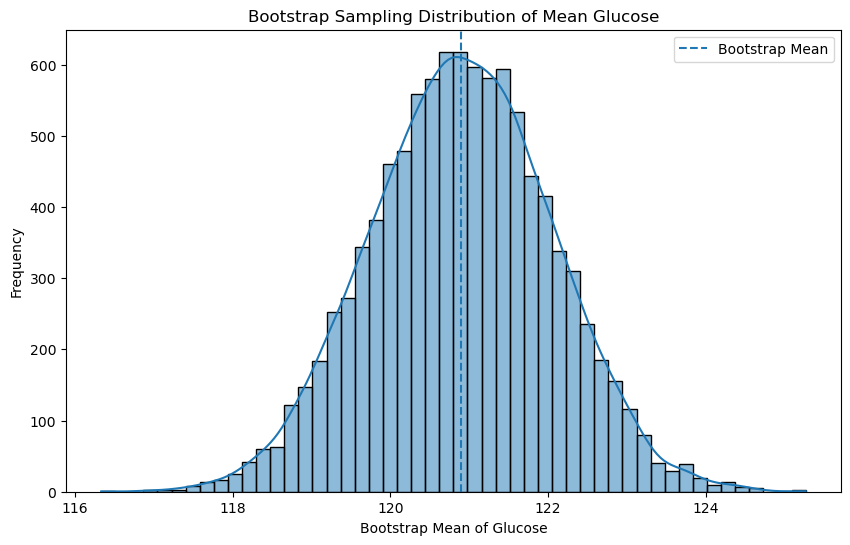

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    bootstrap_means,
    bins=50,
    kde=True
)

plt.axvline(
    np.mean(bootstrap_means),
    linestyle="--",
    label="Bootstrap Mean"
)

plt.title("Bootstrap Sampling Distribution of Mean Glucose")
plt.xlabel("Bootstrap Mean of Glucose")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [10]:
lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

print("95% Bootstrap Confidence Interval")
print("-----------------------------------")
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

95% Bootstrap Confidence Interval
-----------------------------------
Lower Bound: 118.69401041666667
Upper Bound: 123.11588541666667


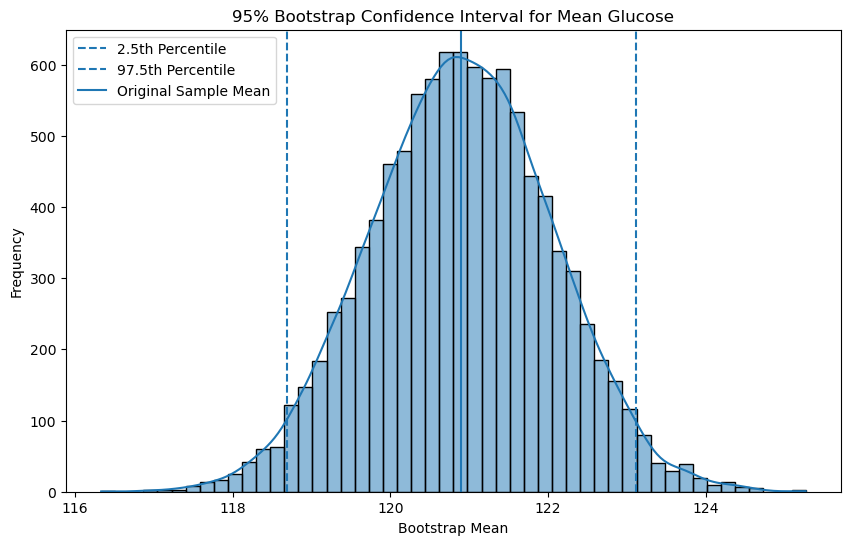

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    bootstrap_means,
    bins=50,
    kde=True
)

plt.axvline(
    lower_bound,
    linestyle="--",
    label="2.5th Percentile"
)

plt.axvline(
    upper_bound,
    linestyle="--",
    label="97.5th Percentile"
)

plt.axvline(
    np.mean(glucose),
    linestyle="-",
    label="Original Sample Mean"
)

plt.title("95% Bootstrap Confidence Interval for Mean Glucose")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [12]:
diabetic = df[df["Outcome"] == 1]["Glucose"]
non_diabetic = df[df["Outcome"] == 0]["Glucose"]

print("Number of diabetic patients:", len(diabetic))
print("Number of non-diabetic patients:", len(non_diabetic))

print("\nMean Glucose - Diabetic:",
      diabetic.mean())

print("Mean Glucose - Non-Diabetic:",
      non_diabetic.mean())

Number of diabetic patients: 268
Number of non-diabetic patients: 500

Mean Glucose - Diabetic: 141.25746268656715
Mean Glucose - Non-Diabetic: 109.98


In [13]:
observed_difference = (
    diabetic.mean() - non_diabetic.mean()
)

print("Observed Difference in Mean Glucose:",
      observed_difference)

Observed Difference in Mean Glucose: 31.277462686567148


In [14]:
np.random.seed(42)

n_permutations = 10000

glucose_values = df["Glucose"].values
outcome_labels = df["Outcome"].values

permutation_differences = []

for i in range(n_permutations):
    
    shuffled_labels = np.random.permutation(outcome_labels)
    
    permuted_diabetic = glucose_values[shuffled_labels == 1]
    permuted_non_diabetic = glucose_values[shuffled_labels == 0]
    
    difference = (
        np.mean(permuted_diabetic)
        - np.mean(permuted_non_diabetic)
    )
    
    permutation_differences.append(difference)

permutation_differences = np.array(permutation_differences)

print("Number of permutations:", n_permutations)
print("Permutation test completed successfully!")

Number of permutations: 10000
Permutation test completed successfully!


In [15]:
print("First 10 Permuted Differences:")
print(permutation_differences[:10])

print("\nMean of Permutation Distribution:",
      np.mean(permutation_differences))

print("Standard Deviation:",
      np.std(permutation_differences, ddof=1))

First 10 Permuted Differences:
[ 0.3339403   4.84450746  1.21083582  0.32820896  0.51161194 -3.24241791
 -2.42283582  4.72414925  1.39997015 -2.3139403 ]

Mean of Permutation Distribution: -0.005983952238805939
Standard Deviation: 2.432676663872259


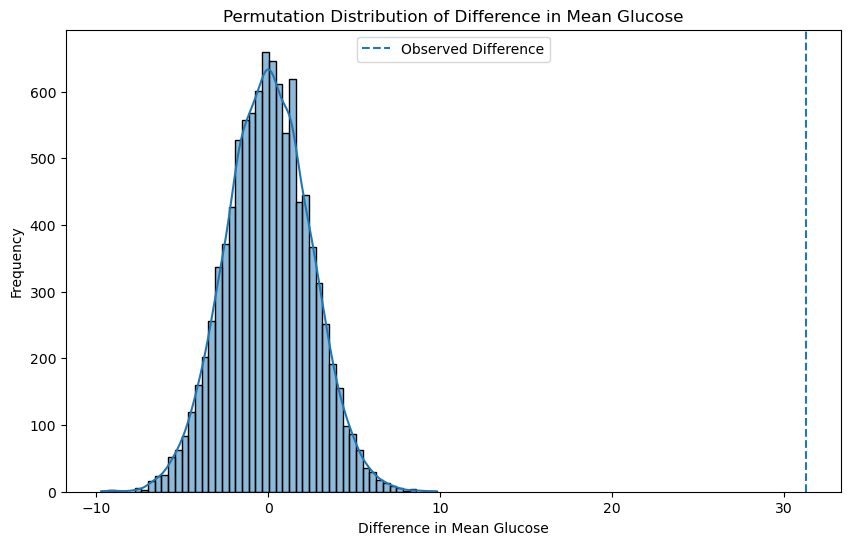

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    permutation_differences,
    bins=50,
    kde=True
)

plt.axvline(
    observed_difference,
    linestyle="--",
    label="Observed Difference"
)

plt.title("Permutation Distribution of Difference in Mean Glucose")
plt.xlabel("Difference in Mean Glucose")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [17]:
p_value = np.mean(
    np.abs(permutation_differences)
    >= np.abs(observed_difference)
)

print("Permutation Test p-value:", p_value)

Permutation Test p-value: 0.0


In [18]:
alpha = 0.05

print("Significance Level:", alpha)
print("p-value:", p_value)

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis (H0)")
    print("There is statistically significant evidence of a difference")
    print("in mean glucose levels between diabetic and non-diabetic groups.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis (H0)")
    print("There is insufficient statistical evidence of a difference")
    print("in mean glucose levels between the two groups.")

Significance Level: 0.05
p-value: 0.0

Decision: Reject the Null Hypothesis (H0)
There is statistically significant evidence of a difference
in mean glucose levels between diabetic and non-diabetic groups.
